In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
import joblib



In [ ]:
# Cargar el dataset

df = pd.read_csv("bank_marketing.csv")
print(' Dataset cargado ')
print("Dimensiones:", df.shape)
df.head()

 Dataset cargado 
Dimensiones: (5000, 15)


,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,y
0,69,retired,married,secondary,no,49009,yes,yes,cellular,1114,8,-1,2,unknown,yes
1,32,unemployed,single,primary,no,38372,yes,no,cellular,1288,5,-1,1,unknown,no
2,89,services,married,secondary,no,8957,no,no,telephone,753,7,-1,2,unknown,yes
3,78,blue-collar,single,tertiary,no,38499,yes,no,cellular,2420,9,20,3,unknown,yes
4,38,student,married,tertiary,no,49548,no,no,cellular,1490,7,-1,1,failure,yes



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        5000 non-null   int64 
 1   job        5000 non-null   object
 2   marital    5000 non-null   object
 3   education  5000 non-null   object
 4   default    5000 non-null   object
 5   balance    5000 non-null   int64 
 6   housing    5000 non-null   object
 7   loan       5000 non-null   object
 8   contact    5000 non-null   object
 9   duration   5000 non-null   int64 
 10  campaign   5000 non-null   int64 
 11  pdays      5000 non-null   int64 
 12  previous   5000 non-null   int64 
 13  poutcome   5000 non-null   object
 14  y          5000 non-null   object
dtypes: int64(6), object(9)
memory usage: 586.1+ KB
None

Valores nulos por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0

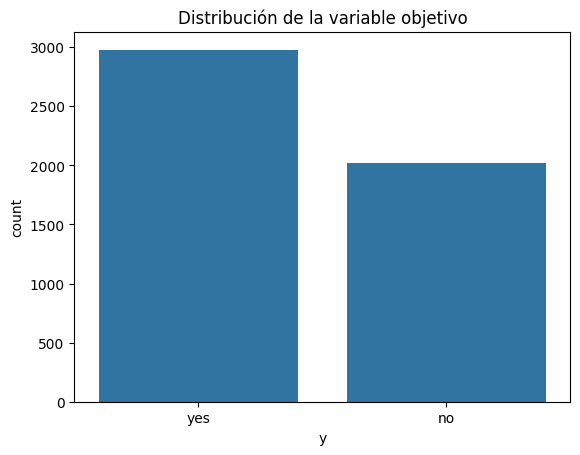

In [ ]:
# Análisis exploratorio
print("\nInformación del dataset:")
print(df.info())

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nDistribución de la variable objetivo:")
print(df["y"].value_counts())

sns.countplot(x="y", data=df)
plt.title("Distribución de la variable objetivo")
plt.show()
# cuántos casos hay de cada clase en la variable Y

In [ ]:
# variables categóricas
le = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col])
 # Convierte las palabras (texto) en números, porque el modelo solo entiende valores numéricos

# Separar variables
X = df.drop("y", axis=1)
y = df["y"]

In [ ]:
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\nTamaños de los conjuntos:")
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Tamaños de los conjuntos:
Entrenamiento: (3500, 14)
Prueba: (1500, 14)


In [ ]:
# Entrenamiento del modelo

modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

In [ ]:
# Evaluación del modelo

print("\nEvaluación del modelo")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC AUC:", round(roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1]), 3))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))



--- Evaluación del modelo ---
Accuracy: 0.657
ROC AUC: 0.684

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.60      0.44      0.51       607
           1       0.68      0.80      0.74       893

    accuracy                           0.66      1500
   macro avg       0.64      0.62      0.62      1500
weighted avg       0.65      0.66      0.65      1500



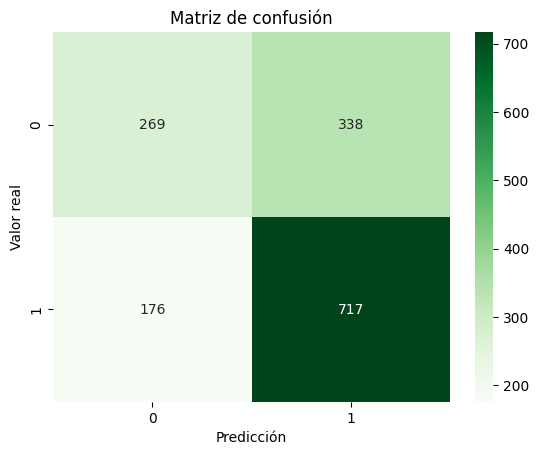

In [ ]:
# Matriz de confusión
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


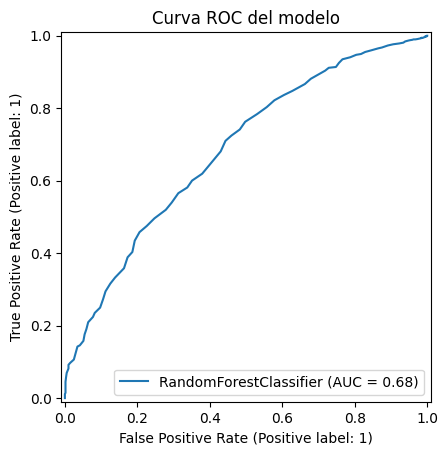

In [ ]:
# Curva ROC
RocCurveDisplay.from_estimator(modelo, X_test, y_test)
plt.title("Curva ROC del modelo")
plt.show()
# Es una métrica de evaluación del modelo, llamada Área bajo la curva ROC.
# Sirve para medir qué tan bien distingue el modelo entre las clases (por ejemplo, “sí” y “no”)


Variables más importantes:
balance      0.194667
duration     0.153200
age          0.144535
campaign     0.084323
job          0.080777
previous     0.063230
education    0.059847
housing      0.048577
marital      0.043133
pdays        0.041440
dtype: float64


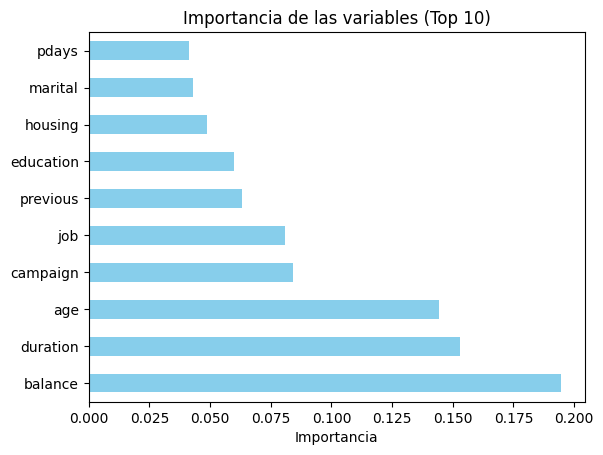

['modelo_random_forest']

In [ ]:
# Importancia de variables y guardar

importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

print("\nVariables más importantes:")
print(importancias.head(10))

importancias.head(10).plot(kind="barh", color="skyblue")
plt.title("Importancia de las variables (Top 10)")
plt.xlabel("Importancia")
plt.show()
# muestra qué variables fueron más importantes para el modelo Random Forest al hacer sus decisiones


joblib.dump(modelo, "modelo_random_forest")
# Guarda el modelo entrenado en un archivo
